# UPI Fraud Detection Using Machine Learning


## 1. Import Libraries


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset


In [5]:
df = pd.read_csv("upi_fraud_dataset.csv")

## 3. Data Understanding


In [7]:
df.head()

,Id,trans_hour,trans_day,trans_month,trans_year,category,upi_number,age,trans_amount,state,zip,fraud_risk
0,0,0,1,1,2022,12,9957000001,54,66.21,22,49879,0
1,1,1,1,1,2022,3,9957000002,15,55.81,14,62668,0
2,2,3,1,1,2022,8,9957000003,60,8.68,4,96037,0
3,3,6,1,1,2022,4,9957000004,44,89.52,40,29911,0
4,4,6,1,1,2022,0,9957000005,72,1.90,38,16421,0


In [8]:
df.shape

(2666, 12)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2666 non-null   int64  
 1   trans_hour    2666 non-null   int64  
 2   trans_day     2666 non-null   int64  
 3   trans_month   2666 non-null   int64  
 4   trans_year    2666 non-null   int64  
 5   category      2666 non-null   int64  
 6   upi_number    2666 non-null   int64  
 7   age           2666 non-null   int64  
 8   trans_amount  2666 non-null   float64
 9   state         2666 non-null   int64  
 10  zip           2666 non-null   int64  
 11  fraud_risk    2666 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 250.1 KB


In [10]:
df.describe()

,Id,trans_hour,trans_day,trans_month,trans_year,category,upi_number,age,trans_amount,state,zip,fraud_risk
count,2666.000000,2666.000000,2666.000000,2666.000000,2666.0,2666.000000,2.666000e+03,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,1332.501500,13.383721,13.552138,3.868717,2022.0,6.800075,8.030152e+09,46.098275,329.844299,27.153788,48219.701800,0.591898
std,769.753574,8.669769,10.316915,3.198150,0.0,3.826561,1.012387e+09,18.863370,385.964247,14.084107,26617.172444,0.491574
min,0.000000,0.000000,1.000000,1.000000,2022.0,0.000000,6.900000e+09,14.000000,1.020000,0.000000,1330.000000,0.000000
25%,666.250000,3.000000,3.000000,2.000000,2022.0,4.000000,7.086000e+09,31.000000,20.987500,15.000000,25132.750000,0.000000
50%,1332.500000,15.000000,15.000000,3.000000,2022.0,7.000000,7.662001e+09,45.000000,113.255000,29.000000,48088.000000,1.000000
75%,1998.750000,22.000000,23.000000,5.000000,2022.0,11.000000,8.876000e+09,58.000000,715.187500,38.000000,68881.000000,1.000000
max,2665.000000,23.000000,31.000000,12.000000,2022.0,13.000000,9.957000e+09,94.000000,3413.050000,50.000000,99783.000000,1.000000


In [11]:
df.duplicated().sum()

0

In [12]:
print("Missing values by column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())


Missing values by column:
Id              0
trans_hour      0
trans_day       0
trans_month     0
trans_year      0
category        0
upi_number      0
age             0
trans_amount    0
state           0
zip             0
fraud_risk      0
dtype: int64

Total missing values: 0
Duplicate rows: 0


## 4. Data Cleaning


In [14]:
df = df.drop(columns = ["Id", "upi_number","trans_year"])

In [15]:
df.shape

(2666, 9)

## 5. Exploratory Data Analysis (EDA)


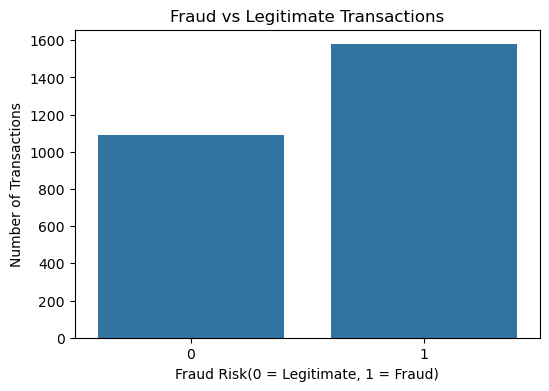

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x = "fraud_risk")

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Fraud Risk(0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

In [18]:
df["fraud_risk"].value_counts()

fraud_risk
1    1578
0    1088
Name: count, dtype: int64

In [19]:
df["fraud_risk"].value_counts(normalize = True) * 100

fraud_risk
1    59.189797
0    40.810203
Name: proportion, dtype: float64

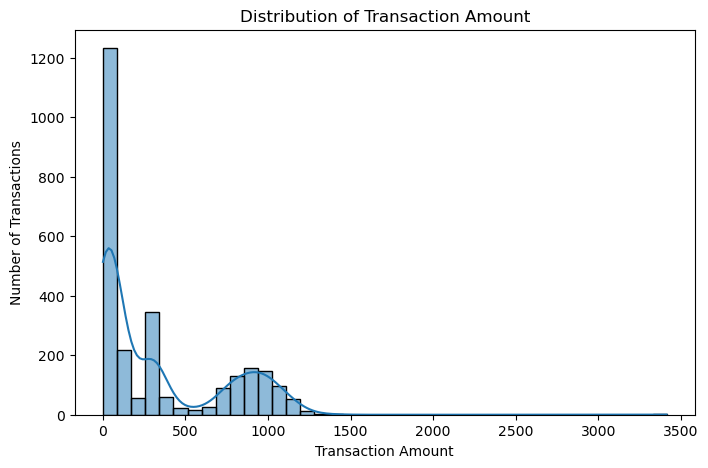

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x = "trans_amount", bins = 40, kde = True)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")

plt.show()

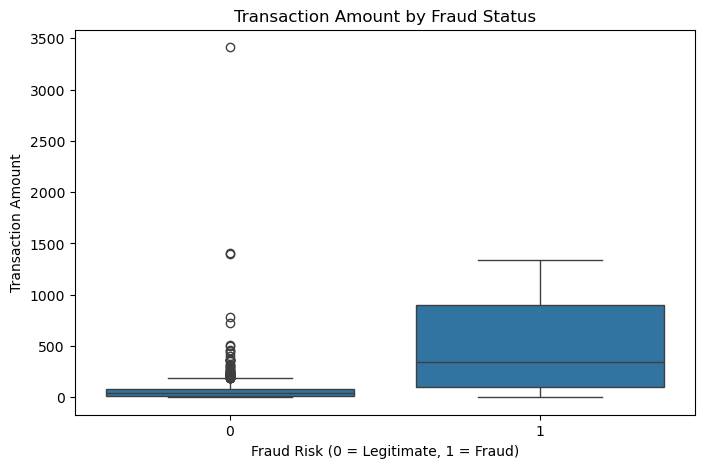

In [21]:
plt.figure(figsize = (8,5))

sns.boxplot(data=df, x = "fraud_risk", y = "trans_amount")

plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Fraud Risk (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

In [22]:
df.groupby("fraud_risk")["trans_amount"].agg(["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
fraud_risk,,,,,
0,1088,66.849090,44.98,1.02,3413.05
1,1578,511.174328,347.77,4.50,1334.07


In [23]:
df["trans_amount"].describe()

count    2666.000000
mean      329.844299
std       385.964247
min         1.020000
25%        20.987500
50%       113.255000
75%       715.187500
max      3413.050000
Name: trans_amount, dtype: float64

In [24]:
Q1 = df["trans_amount"].quantile(0.25)
Q3 = df["trans_amount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -1020.3125000000002
Upper Bound: 1756.4875000000002


In [25]:
outliers = df[
    (df["trans_amount"] < lower_bound) |
    (df["trans_amount"] > upper_bound)
]

outliers[["trans_amount", "fraud_risk"]]

,trans_amount,fraud_risk
1438,3413.05,0


In [26]:
df["trans_hour"].value_counts().sort_index()

trans_hour
0     173
1     194
2     150
3     153
4      57
5      47
6      41
7      55
8      56
9      54
10     51
11     39
12     53
13     68
14     78
15     79
16     79
17     61
18     70
19     70
20     75
21     78
22    420
23    465
Name: count, dtype: int64

In [27]:
fraud_by_hour = df.groupby("trans_hour")["fraud_risk"].mean() * 100

fraud_by_hour

trans_hour
0     83.236994
1     82.989691
2     79.333333
3     80.392157
4     21.052632
5     23.404255
6     24.390244
7     32.727273
8     14.285714
9     33.333333
10    17.647059
11    23.076923
12    16.981132
13    26.470588
14    24.358974
15    27.848101
16    26.582278
17    27.868852
18    18.571429
19    21.428571
20    17.333333
21    20.512821
22    88.809524
23    86.021505
Name: fraud_risk, dtype: float64

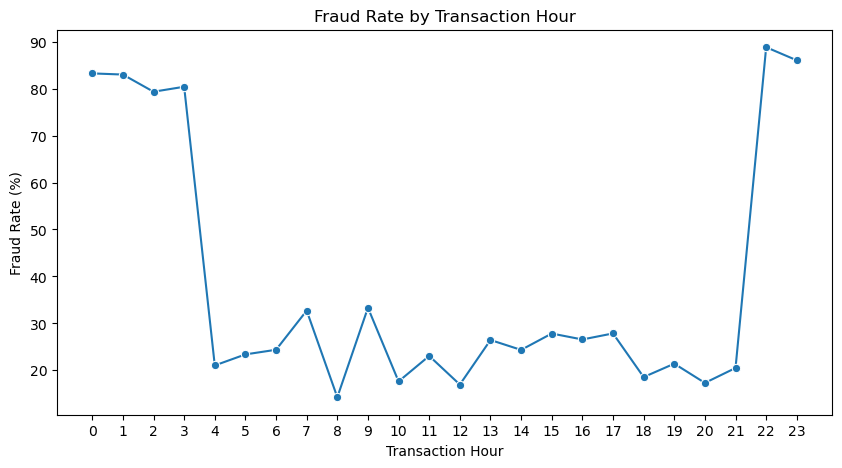

In [28]:
plt.figure(figsize=(10, 5))

sns.lineplot(x=fraud_by_hour.index, y=fraud_by_hour.values, marker="o")

plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))

plt.show()

In [29]:
df["category"].value_counts().sort_index()

category
0     110
1     113
2     243
3      81
4     462
5     121
6     157
7     155
8     232
9     109
10    132
11    426
12    261
13     64
Name: count, dtype: int64

In [30]:
fraud_by_category = df.groupby("category")["fraud_risk"].mean() * 100

fraud_by_category.sort_values(ascending=False)

category
11    80.281690
4     79.004329
8     78.448276
12    65.517241
2     58.024691
9     51.376147
13    46.875000
0     41.818182
7     40.645161
10    37.878788
3     33.333333
5     29.752066
1     29.203540
6     22.929936
Name: fraud_risk, dtype: float64

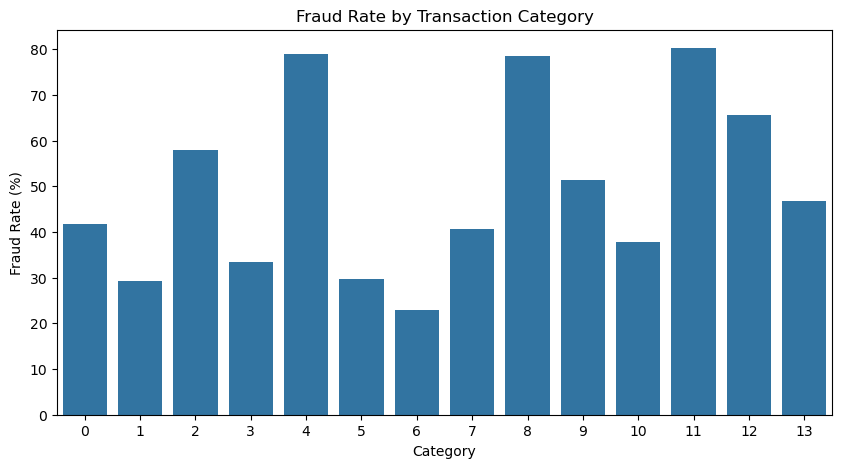

In [31]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=fraud_by_category.index,
    y=fraud_by_category.values
)

plt.title("Fraud Rate by Transaction Category")
plt.xlabel("Category")
plt.ylabel("Fraud Rate (%)")

plt.show()

## 6. Feature and Target Separation


In [33]:
X = df.drop("fraud_risk",axis = 1)
y = df["fraud_risk"]

## 7. Train-Test Split


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

## 8. Data Preprocessing


In [37]:
numeric_features = [
    "trans_hour",
    "trans_day",
    "trans_month",
    "age",
    "trans_amount"
]

In [38]:
categorical_features = [
    "category",
    "state",
]

In [39]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [40]:
X_train_transformed = preprocessor.fit_transform(X_train)

print("Original features:",X_train.shape)
print("Transformed features:", X_train_transformed.shape)

Original features: (2132, 8)
Transformed features: (2132, 68)


## 9. Logistic Regression


In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)
logistic_pipeline.fit(X_train,y_train)

y_pred_lr = logistic_pipeline.predict(X_test)

## 10. Logistic Regression Evaluation


In [44]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report)

In [45]:
accuracy = accuracy_score(y_test, y_pred_lr)
print("Accuracy:", accuracy)

Accuracy: 0.7921348314606742


In [46]:
precision = precision_score(y_test, y_pred_lr)
print("Precision:", precision)

Precision: 0.840531561461794


In [47]:
recall = recall_score(y_test, y_pred_lr)
print("Recall:",recall)

Recall: 0.8006329113924051


In [48]:
f1 = f1_score(y_test, y_pred_lr)
print("F1 Score:", f1)

F1 Score: 0.820097244732577


In [49]:
y_prob_lr = logistic_pipeline.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob_lr)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8970502845198003


In [50]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.73      0.78      0.75       218
           1       0.84      0.80      0.82       316

    accuracy                           0.79       534
   macro avg       0.79      0.79      0.79       534
weighted avg       0.80      0.79      0.79       534



In [51]:
cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[170  48]
 [ 63 253]]


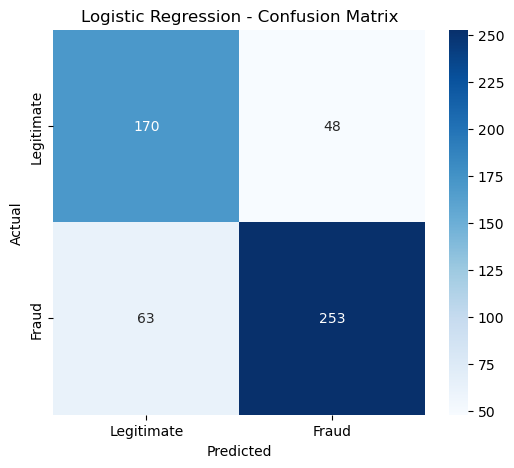

In [52]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [53]:
logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc
}

results_df = pd.DataFrame([logistic_results])

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.792135,0.840532,0.800633,0.820097,0.89705


## 11. Random Forest


In [55]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_pipeline.fit(X_train, y_train)

y_pred_rf = random_forest_pipeline.predict(X_test)

In [56]:
y_prob_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]

In [57]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       218
           1       0.98      0.96      0.97       316

    accuracy                           0.97       534
   macro avg       0.97      0.97      0.97       534
weighted avg       0.97      0.97      0.97       534



In [58]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC  :", rf_roc_auc)

Accuracy : 0.9681647940074907
Precision: 0.9838187702265372
Recall   : 0.9620253164556962
F1 Score : 0.9728
ROC-AUC  : 0.9949628382301707


In [59]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[213   5]
 [ 12 304]]


## 12. Random Forest Cross-Validation


In [61]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [62]:
cv_results = cross_validate(
    random_forest_pipeline,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=-1
)

In [63]:
cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean()
    ],
    "Std": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std()
    ]
})

cv_summary

,Metric,Mean,Std
0,Accuracy,0.960612,0.007425
1,Precision,0.967050,0.004554
2,Recall,0.966407,0.012478
3,F1 Score,0.966680,0.006479
4,ROC-AUC,0.994045,0.001711


## 13. Random Forest Feature Importance


In [65]:
feature_names = (
    random_forest_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_names

array(['num__trans_hour', 'num__trans_day', 'num__trans_month',
       'num__age', 'num__trans_amount', 'cat__category_0',
       'cat__category_1', 'cat__category_2', 'cat__category_3',
       'cat__category_4', 'cat__category_5', 'cat__category_6',
       'cat__category_7', 'cat__category_8', 'cat__category_9',
       'cat__category_10', 'cat__category_11', 'cat__category_12',
       'cat__category_13', 'cat__state_0', 'cat__state_1', 'cat__state_2',
       'cat__state_3', 'cat__state_4', 'cat__state_5', 'cat__state_6',
       'cat__state_7', 'cat__state_9', 'cat__state_10', 'cat__state_12',
       'cat__state_13', 'cat__state_14', 'cat__state_15', 'cat__state_16',
       'cat__state_17', 'cat__state_18', 'cat__state_19', 'cat__state_20',
       'cat__state_21', 'cat__state_22', 'cat__state_23', 'cat__state_24',
       'cat__state_25', 'cat__state_26', 'cat__state_27', 'cat__state_28',
       'cat__state_29', 'cat__state_30', 'cat__state_31', 'cat__state_32',
       'cat__state_33', 

In [66]:
importances = (
    random_forest_pipeline
    .named_steps["model"]
    .feature_importances_
)

In [67]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(15)

,Feature,Importance
4,num__trans_amount,0.445672
0,num__trans_hour,0.184119
3,num__age,0.051048
1,num__trans_day,0.035358
2,num__trans_month,0.024638
7,cat__category_2,0.022399
9,cat__category_4,0.019477
11,cat__category_6,0.017931
16,cat__category_11,0.017490
6,cat__category_1,0.011403


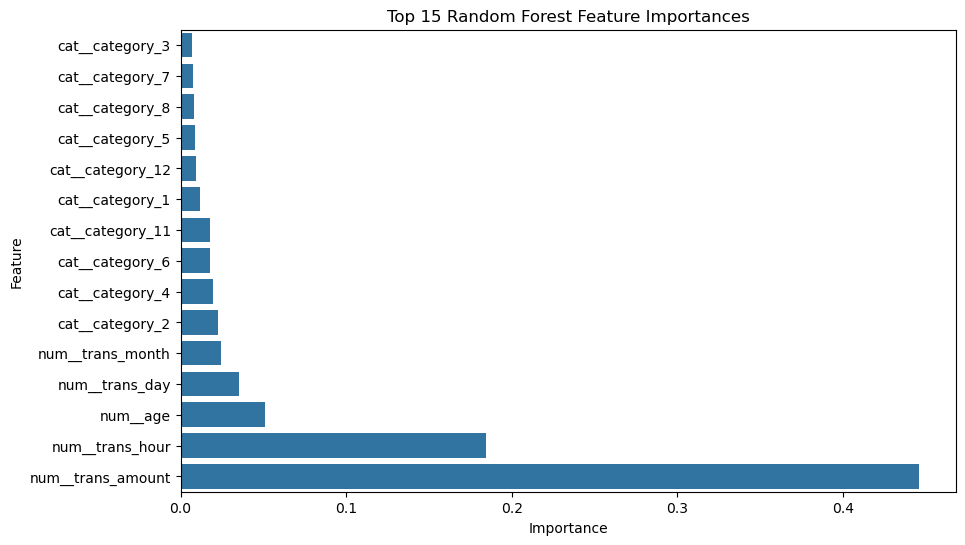

In [68]:
top_features = feature_importance_df.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## 14. XGBoost


In [70]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1
        ))
    ]
)

xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)

In [71]:
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

In [72]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95       218
           1       0.97      0.96      0.97       316

    accuracy                           0.96       534
   macro avg       0.96      0.96      0.96       534
weighted avg       0.96      0.96      0.96       534



In [73]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)

print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)
print("ROC-AUC  :", xgb_roc_auc)

Accuracy : 0.9606741573033708
Precision: 0.9712460063897763
Recall   : 0.9620253164556962
F1 Score : 0.9666136724960255
ROC-AUC  : 0.9951225177099059


## 15. Model Comparison


In [75]:
initial_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        f1,
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ]
})


## 16. XGBoost Hyperparameter Tuning


In [77]:
from sklearn.model_selection import RandomizedSearchCV

xgb_param_grid = {
    "model__n_estimators": [100, 200, 300, 400],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5]
}

In [78]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [79]:
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring="recall",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['trans_hour',
                                                                                'trans_day',
                                                                                'trans_month',
                                                                                'age',
                                                                                'trans_amount']),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['category',
                                                                                'state'])])),
                                             ('model',
                                              XGBClassifier(base_score=None,...
                                                            num_parallel_tree=None,
                                                            random_state=42, ...))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.7, 0.8,
                                                                    0.9, 1.0],
                                        'model__learning_rate': [0.03, 0.05,
                                                                 0.1],
                                        'model__max_depth': [3, 4, 5, 6],
                                        'model__min_child_weight': [1, 3, 5],
                                        'model__n_estimators': [100, 200, 300,
                                                                400],
                                        'model__subsample': [0.7, 0.8, 0.9,
                                                             1.0]},
                   random_state=42, scoring='recall', verbose=1)

In [80]:
print("Best CV Recall:", xgb_random_search.best_score_)
print("Best Parameters:")
print(xgb_random_search.best_params_)

Best CV Recall: 0.9683072965681662
Best Parameters:
{'model__subsample': 0.8, 'model__n_estimators': 300, 'model__min_child_weight': 1, 'model__max_depth': 4, 'model__learning_rate': 0.1, 'model__colsample_bytree': 1.0}


In [81]:
tuned_xgb = xgb_random_search.best_estimator_

y_pred_tuned_xgb = tuned_xgb.predict(X_test)

y_prob_tuned_xgb = tuned_xgb.predict_proba(X_test)[:, 1]

In [82]:
tuned_xgb_accuracy = accuracy_score(
    y_test,
    y_pred_tuned_xgb
)

tuned_xgb_precision = precision_score(
    y_test,
    y_pred_tuned_xgb
)

tuned_xgb_recall = recall_score(
    y_test,
    y_pred_tuned_xgb
)

tuned_xgb_f1 = f1_score(
    y_test,
    y_pred_tuned_xgb
)

tuned_xgb_roc_auc = roc_auc_score(
    y_test,
    y_prob_tuned_xgb
)

In [83]:
print("Tuned XGBoost")
print("----------------")
print("Accuracy :", tuned_xgb_accuracy)
print("Precision:", tuned_xgb_precision)
print("Recall   :", tuned_xgb_recall)
print("F1 Score :", tuned_xgb_f1)
print("ROC-AUC  :", tuned_xgb_roc_auc)

Tuned XGBoost
----------------
Accuracy : 0.9625468164794008
Precision: 0.9683544303797469
Recall   : 0.9683544303797469
F1 Score : 0.9683544303797469
ROC-AUC  : 0.9953402624549994


In [84]:
print(classification_report(y_test, y_pred_tuned_xgb))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       218
           1       0.97      0.97      0.97       316

    accuracy                           0.96       534
   macro avg       0.96      0.96      0.96       534
weighted avg       0.96      0.96      0.96       534



## 17. Final Model Comparison


In [86]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Tuned XGBoost"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        xgb_accuracy,
        tuned_xgb_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        xgb_precision,
        tuned_xgb_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        xgb_recall,
        tuned_xgb_recall
    ],
    "F1 Score": [
        f1,
        rf_f1,
        xgb_f1,
        tuned_xgb_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc,
        xgb_roc_auc,
        tuned_xgb_roc_auc
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7921,0.8405,0.8006,0.8201,0.8971
1,Random Forest,0.9682,0.9838,0.9620,0.9728,0.9950
2,XGBoost,0.9607,0.9712,0.9620,0.9666,0.9951
3,Tuned XGBoost,0.9625,0.9684,0.9684,0.9684,0.9953


## 18. Final Model Evaluation


In [88]:
y_pred = random_forest_pipeline.predict(X_test)
y_prob = random_forest_pipeline.predict_proba(X_test)[:, 1]

print("Final Random Forest Model")
print("-------------------------")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

Final Random Forest Model
-------------------------
Accuracy : 0.9682
Precision: 0.9838
Recall   : 0.962
F1 Score : 0.9728
ROC-AUC  : 0.995


In [89]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[213   5]
 [ 12 304]]


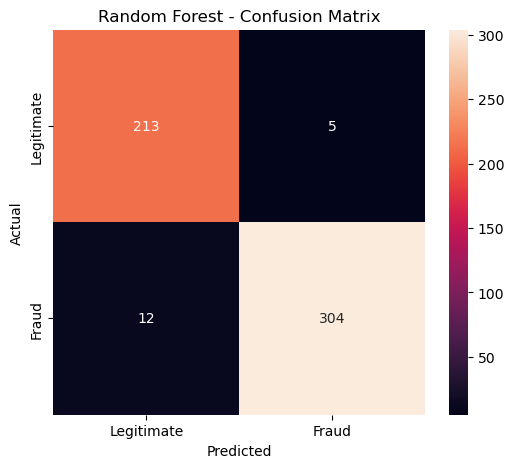

In [90]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")

plt.show()

In [91]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Legitimate", "Fraud"]
))

              precision    recall  f1-score   support

  Legitimate       0.95      0.98      0.96       218
       Fraud       0.98      0.96      0.97       316

    accuracy                           0.97       534
   macro avg       0.97      0.97      0.97       534
weighted avg       0.97      0.97      0.97       534



## 19. Final Conclusion


The Random Forest model performed strongly in detecting fraudulent UPI transactions, achieving approximately 97% accuracy, with high precision, recall, and F1-score for the fraud class. Its ROC-AUC of approximately 0.995 indicates excellent ability to distinguish fraudulent transactions from legitimate ones on the test dataset.

I compared Logistic Regression, Random Forest, XGBoost and Tuned XGBoost. Random Forest was selected as the final model because it provided the best overall balance of precision, recall and F1 Score.

I also explored Isolation Forest as an unsupervised anomaly detection approach. This was treated as an additional experiment because the dataset already contains a fraud label.

However, these results should be interpreted cautiously because the dataset is synthetic and may contain patterns that do not fully represent real-world UPI transactions. Therefore, the model's performance should not be assumed to generalize directly to real banking systems.

Overall, the project demonstrates how machine learning can be applied to identify potentially fraudulent UPI transactions and provides a strong foundation for further development using real-world data.